## 1. Import Library

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from scipy.ndimage import convolve  # Digunakan untuk Haar Wavelet manual
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns

## 2. Data Loading

Pastikan struktur folder dataset sebagai berikut:
```
PROJECT-PCD-34/
└── dataset/
    ├── blast/
    │   ├── image1.jpg
    │   └── ...
    ├── blight/
    │   ├── image1.jpg
    │   └── ...
    └── tungro/
        ├── image1.jpg
        └── ...
```

> **Catatan:** Dataset ini memiliki **3 kelas** penyakit daun padi: `blast`, `blight`, dan `tungro`.

In [2]:
DATASET_PATH = "dataset"
TARGET_SIZE  = (256, 256)
KELAS_VALID  = ['blast', 'blight', 'tungro']

data      = []
labels    = []
file_name = []

for sub_folder in sorted(os.listdir(DATASET_PATH)):
    sub_folder_path = os.path.join(DATASET_PATH, sub_folder)

    if not os.path.isdir(sub_folder_path):
        continue
    if sub_folder not in KELAS_VALID:
        print(f"⚠️  Folder '{sub_folder}' dilewati (bukan kelas dataset)")
        continue

    sub_folder_files = os.listdir(sub_folder_path)
    print(f"📂 Memuat kelas '{sub_folder}': {len(sub_folder_files)} file...")

    for filename in sub_folder_files:
        img_path = os.path.join(sub_folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            print(f"   ⚠️  Gagal membaca: {filename}")
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        img = cv.resize(img, TARGET_SIZE, interpolation=cv.INTER_AREA)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data      = np.array(data, dtype=np.uint8)
labels    = np.array(labels)

print()
print(f"✅ Total gambar berhasil dimuat: {len(data)}")
print(f"   Ukuran gambar : {data[0].shape}")
print(f"   Tipe data     : {data.dtype}")
print(f"📊 Distribusi per kelas:")
for kelas in KELAS_VALID:
    jumlah = np.sum(labels == kelas)
    print(f"   {kelas:10s}: {jumlah} gambar")

📂 Memuat kelas 'blast': 80 file...
📂 Memuat kelas 'blight': 80 file...
📂 Memuat kelas 'tungro': 80 file...

✅ Total gambar berhasil dimuat: 240
   Ukuran gambar : (256, 256)
   Tipe data     : uint8
📊 Distribusi per kelas:
   blast     : 80 gambar
   blight    : 80 gambar
   tungro    : 80 gambar


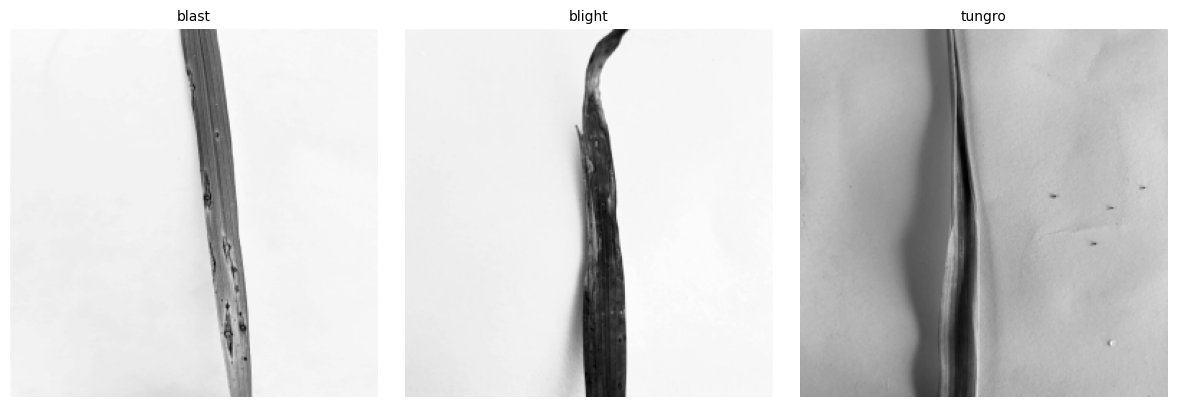

In [3]:
unique_labels = np.unique(labels)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels == kelas)[0][0]
    ax.imshow(data[idx], cmap='gray')
    ax.set_title(kelas, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Data Augmentation

In [4]:
data_augmented      = list(data)
labels_augmented    = list(labels)
file_name_augmented = list(file_name)

for i in range(len(data)):
    img   = data[i]
    label = labels[i]
    fname = file_name[i]
    name, ext = os.path.splitext(fname)

    # Flip Horizontal
    flipped_h = cv.flip(img, 1)
    data_augmented.append(flipped_h)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipH{ext}")

    # Flip Vertikal
    flipped_v = cv.flip(img, 0)
    data_augmented.append(flipped_v)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_flipV{ext}")

    # Rotasi 90°
    rotated = cv.rotate(img, cv.ROTATE_90_CLOCKWISE)
    data_augmented.append(rotated)
    labels_augmented.append(label)
    file_name_augmented.append(f"{name}_rot90{ext}")

data_augmented      = np.array(data_augmented, dtype=object)
labels_augmented    = np.array(labels_augmented)
file_name_augmented = np.array(file_name_augmented)

print(f"Data sebelum augmentasi : {len(data)}")
print(f"Data setelah augmentasi : {len(data_augmented)}")

Data sebelum augmentasi : 240
Data setelah augmentasi : 960


## 4. Preprocessing — Percobaan 3
### Pipeline: Grayscale (sudah dilakukan saat loading) → Resize → Gausian Blur → Normalisasi

In [25]:
def resize(image, targetSize=(256, 256)):
    return cv.resize(image, targetSize, interpolation=cv.INTER_AREA)

def normalisasi(image):
    return image.astype(np.float32) / 255.0

def clahePreprocessing(image):
    clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    hasil = clahe.apply(image)
    return hasil

def thresholding(image):
    nilaiThreshold = np.mean(image)
    tinggi, lebar = image.shape
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)
    for y in range(tinggi):
        for x in range(lebar):
            if image[y, x] >= nilaiThreshold:
                hasil[y, x] = 0
            else:
                hasil[y, x] = 255

    return hasil

def dilasi(image, ukuranKernel=3):
    tinggi, lebar = image.shape
    pad = ukuranKernel // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)

    for y in range(tinggi):
        for x in range(lebar):
            area = padded[y:y + ukuranKernel, x:x + ukuranKernel]
            if np.any(area == 255):
                hasil[y, x] = 255
            else:
                hasil[y, x] = 0
    return hasil

def erosi(image, ukuranKernel=3):
    tinggi, lebar = image.shape
    pad = ukuranKernel // 2
    padded = np.pad(image, ((pad, pad), (pad, pad)), mode='constant', constant_values=0)
    hasil = np.zeros((tinggi, lebar), dtype=np.uint8)

    for y in range(tinggi):
        for x in range(lebar):
            area = padded[y:y + ukuranKernel, x:x + ukuranKernel]
            if np.all(area == 255):
                hasil[y, x] = 255
            else:
                hasil[y, x] = 0
    return hasil

def closingMorfologi(image, ukuranKernel=3):
    hasilDilasi = dilasi(image, ukuranKernel)
    hasilClosing = erosi(hasilDilasi, ukuranKernel)
    return hasilClosing

def prepro4(image, targetSize=(256, 256)):
    img = image.astype(np.uint8)

    img = resize(img, targetSize)
    img = clahePreprocessing(img)
    img = thresholding(img)
    img = closingMorfologi(img, ukuranKernel=3)
    img = normalisasi(img)
    imgUint8 = (img * 255).astype(np.uint8)
    return imgUint8

In [26]:
dataPreprocessed = []

for i in range(len(data_augmented)):
    img_prep = prepro4(data_augmented[i], TARGET_SIZE)
    dataPreprocessed.append(img_prep)

dataPreprocessed = np.array(dataPreprocessed)

print(f"   Preprocessing selesai!")
print(f"   Jumlah gambar    : {len(dataPreprocessed)}")
print(f"   Ukuran gambar    : {dataPreprocessed[0].shape}")
print(f"   Tipe data        : {dataPreprocessed[0].dtype}")
print(f"   Nilai min / max  : {dataPreprocessed[0].min()} / {dataPreprocessed[0].max()}")

   Preprocessing selesai!
   Jumlah gambar    : 960
   Ukuran gambar    : (256, 256)
   Tipe data        : uint8
   Nilai min / max  : 0 / 255


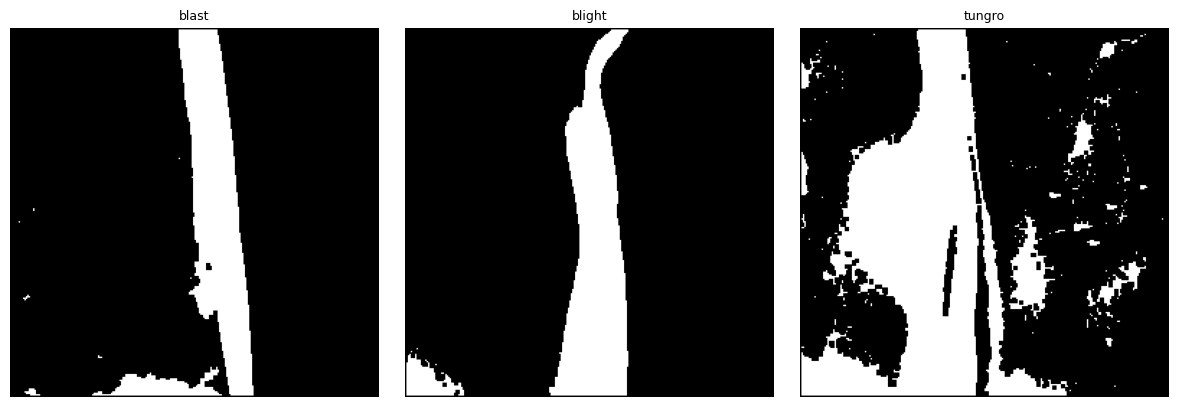

In [27]:
unique_labels = np.unique(labels_augmented)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]
    ax.imshow(dataPreprocessed[idx], cmap='gray', vmin=0, vmax=255)
    ax.set_title(kelas, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

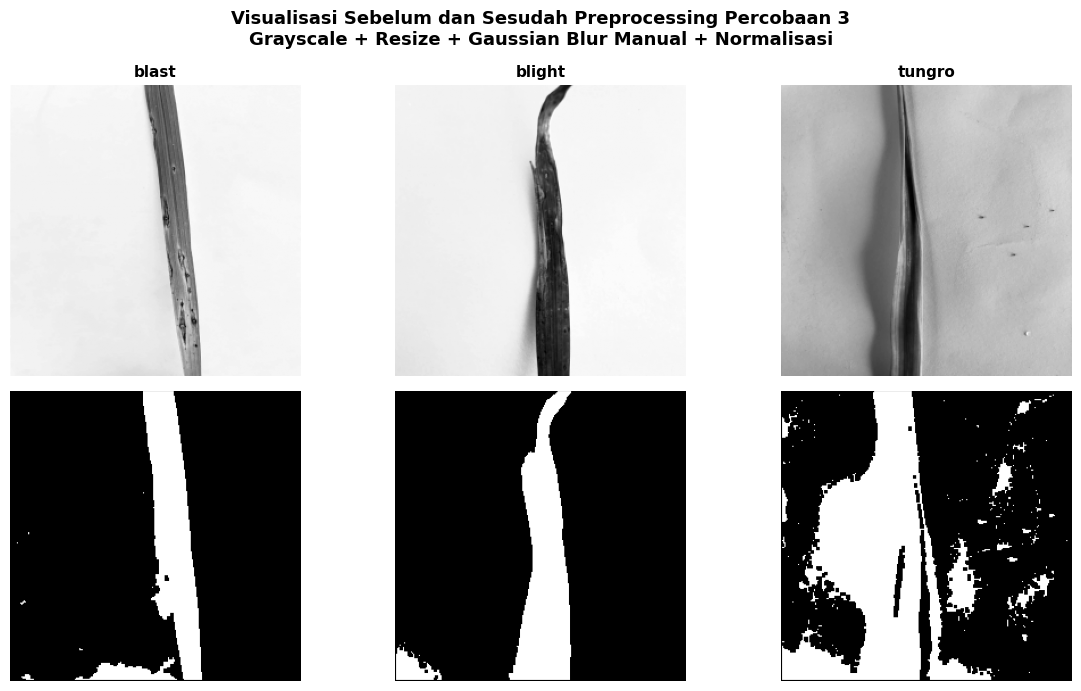

In [28]:
# VISUALISASI PERBANDINGAN SEBELUM DAN SESUDAH PREPROCESSING

unique_labels = np.unique(labels_augmented)
n_kelas = len(unique_labels)
fig, axes = plt.subplots(2, n_kelas, figsize=(12, 7))

for col, kelas in enumerate(unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]

    gambar_asli = data_augmented[idx].astype(np.uint8)
    gambar_prepro = dataPreprocessed[idx]

    # [PERUBAHAN] Baris 1: sebelum preprocessing
    axes[0, col].imshow(gambar_asli, cmap='gray')
    axes[0, col].set_title(f"{kelas}", fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel("Sebelum", fontsize=11)
    axes[0, col].axis('off')

    # [PERUBAHAN] Baris 2: sesudah preprocessing
    axes[1, col].imshow(gambar_prepro, cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_ylabel("Sesudah", fontsize=11)
    axes[1, col].axis('off')

plt.suptitle(
    "Visualisasi Sebelum dan Sesudah Preprocessing Percobaan 3\n"
    "Grayscale + Resize + Gaussian Blur Manual + Normalisasi",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 5. Ekstraksi Fitur GLCM

In [29]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut tidak valid. Gunakan: 0, 45, 90, atau 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [30]:
Derajat0   = []
Derajat45  = []
Derajat90  = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960


In [31]:
Kontras0, Kontras45, Kontras90, Kontras135                     = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135          = [], [], [], []
entropy0, entropy45, entropy90, entropy135                      = [], [], [], []
ASM0, ASM45, ASM90, ASM135                                      = [], [], [], []
energy0, energy45, energy90, energy135                          = [], [], [], []
correlation0, correlation45, correlation90, correlation135      = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))

    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

## 6. Ekstraksi Fitur Wavelet (Haar — Implementasi Manual)

In [32]:
HAAR_LP = np.array([1/np.sqrt(2), 1/np.sqrt(2)])
HAAR_HP = np.array([1/np.sqrt(2), -1/np.sqrt(2)])

def haar_dwt2d_level1(image):
    img = image.astype(np.float32)

    from scipy.ndimage import convolve1d
    L_row = convolve1d(img,    HAAR_LP, axis=1, mode='wrap')[:, ::2]
    H_row = convolve1d(img,    HAAR_HP, axis=1, mode='wrap')[:, ::2]

    LL = convolve1d(L_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    LH = convolve1d(L_row, HAAR_HP, axis=0, mode='wrap')[::2, :]
    HL = convolve1d(H_row, HAAR_LP, axis=0, mode='wrap')[::2, :]
    HH = convolve1d(H_row, HAAR_HP, axis=0, mode='wrap')[::2, :]

    return LL, LH, HL, HH


def ekstraksi_wavelet(image, level=2):
    fitur = []
    current = image.astype(np.float32)

    for lv in range(1, level + 1):
        LL, LH, HL, HH = haar_dwt2d_level1(current)

        if lv == level:
            fitur.append(np.mean(LL))
            fitur.append(np.std(LL))

        # Detail sub-bands setiap level
        fitur.append(np.mean(LH));  fitur.append(np.std(LH))
        fitur.append(np.mean(HL));  fitur.append(np.std(HL))
        fitur.append(np.mean(HH));  fitur.append(np.std(HH))

        # LL menjadi input level berikutnya
        current = LL

    return fitur

## 7. Simpan Hasil Ekstraksi ke CSV

In [33]:
wavelet_features = []
for i in range(len(dataPreprocessed)):
    wav_feat = ekstraksi_wavelet(dataPreprocessed[i], level=2)
    wavelet_features.append(wav_feat)
    if (i + 1) % 100 == 0:
        print(f"   Progress: {i+1}/{len(dataPreprocessed)}")

wavelet_features = np.array(wavelet_features)

n_wav = wavelet_features.shape[1]
wav_col_names = (
    ['Wav_LL_mean', 'Wav_LL_std'] +
    ['Wav_LH_L2_mean', 'Wav_LH_L2_std',
     'Wav_HL_L2_mean', 'Wav_HL_L2_std',
     'Wav_HH_L2_mean', 'Wav_HH_L2_std'] +
    ['Wav_LH_L1_mean', 'Wav_LH_L1_std',
     'Wav_HL_L1_mean', 'Wav_HL_L1_std',
     'Wav_HH_L1_mean', 'Wav_HH_L1_std']
)

# Buat dictionary semua fitur
dataTable = {
    'Filename' : file_name_augmented,
    'Label'    : labels_augmented,
    # GLCM Features
    'Contrast0': Kontras0,     'Contrast45': Kontras45,     'Contrast90': Kontras90,     'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0,      'Entropy45': entropy45,      'Entropy90': entropy90,      'Entropy135': entropy135,
    'ASM0': ASM0,              'ASM45': ASM45,              'ASM90': ASM90,              'ASM135': ASM135,
    'Energy0': energy0,        'Energy45': energy45,        'Energy90': energy90,        'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}

# Tambahkan fitur Wavelet
for j, col in enumerate(wav_col_names):
    dataTable[col] = wavelet_features[:, j]

df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
print(f"   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'")
print(f"   Shape DataFrame: {hasilEkstrak.shape}")
hasilEkstrak.head()

   Progress: 100/960
   Progress: 200/960
   Progress: 300/960
   Progress: 400/960
   Progress: 500/960
   Progress: 600/960
   Progress: 700/960
   Progress: 800/960
   Progress: 900/960
   CSV berhasil disimpan: 'hasil_ekstraksi_percobaan1.csv'
   Shape DataFrame: (960, 44)


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,Wav_HL_L2_mean,Wav_HL_L2_std,Wav_HH_L2_mean,Wav_HH_L2_std,Wav_LH_L1_mean,Wav_LH_L1_std,Wav_HL_L1_mean,Wav_HL_L1_std,Wav_HH_L1_mean,Wav_HH_L1_std
0,IMG_0448.jpg,blast,639.492188,838.0,386.484375,926.0,0.990166,0.987113,0.994056,0.985760,...,0.085602,8.626001,124.68292,320.65094,0.015564,34.404903,0.233459,54.27518,0.015564,16.337145
1,IMG_0535.jpg,blast,798.867188,1166.0,573.750000,1174.0,0.987715,0.982069,0.991177,0.981946,...,0.031128,10.060005,201.52222,391.31610,0.280151,43.623000,0.217896,57.51484,-0.124512,20.846327
2,IMG_0536.jpg,blast,2055.937500,2896.0,1432.382812,2776.0,0.968383,0.955464,0.977972,0.957309,...,0.311279,17.926985,393.64380,468.15225,-1.151733,66.348090,0.217896,88.29882,0.062256,34.071590
3,IMG_0541.jpg,blast,1663.476562,2506.0,1420.429688,2488.0,0.974418,0.961462,0.978156,0.961738,...,0.101166,17.166069,366.14227,463.70206,-0.295715,66.335000,-1.727600,80.30760,-0.108948,34.891560
4,IMG_0543.jpg,blast,1490.156250,2268.0,1233.164062,2262.0,0.977084,0.965122,0.981036,0.965214,...,0.085602,15.463299,298.31450,439.15660,0.233459,60.793920,-1.758728,79.69922,-0.015564,27.333650


## 8. Feature Selection (Korelasi)

In [34]:
correlation_matrix = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()

threshold = 0.95
columns   = np.full((correlation_matrix.shape[0],), True, dtype=bool)

for i in range(correlation_matrix.shape[0]):
    for j in range(i + 1, correlation_matrix.shape[0]):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new  = hasilEkstrak[select]
y      = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : {hasilEkstrak.drop(columns=['Label','Filename']).shape[1]}")
print(f"Fitur setelah seleksi : {x_new.shape[1]}")
print(f"Fitur yang dipilih    : {list(select)}")

Fitur sebelum seleksi : 42
Fitur setelah seleksi : 10
Fitur yang dipilih    : ['Contrast0', 'Entropy0', 'Wav_LL_mean', 'Wav_LH_L2_mean', 'Wav_HL_L2_mean', 'Wav_HH_L2_std', 'Wav_LH_L1_mean', 'Wav_HL_L1_mean', 'Wav_HL_L1_std', 'Wav_HH_L1_mean']


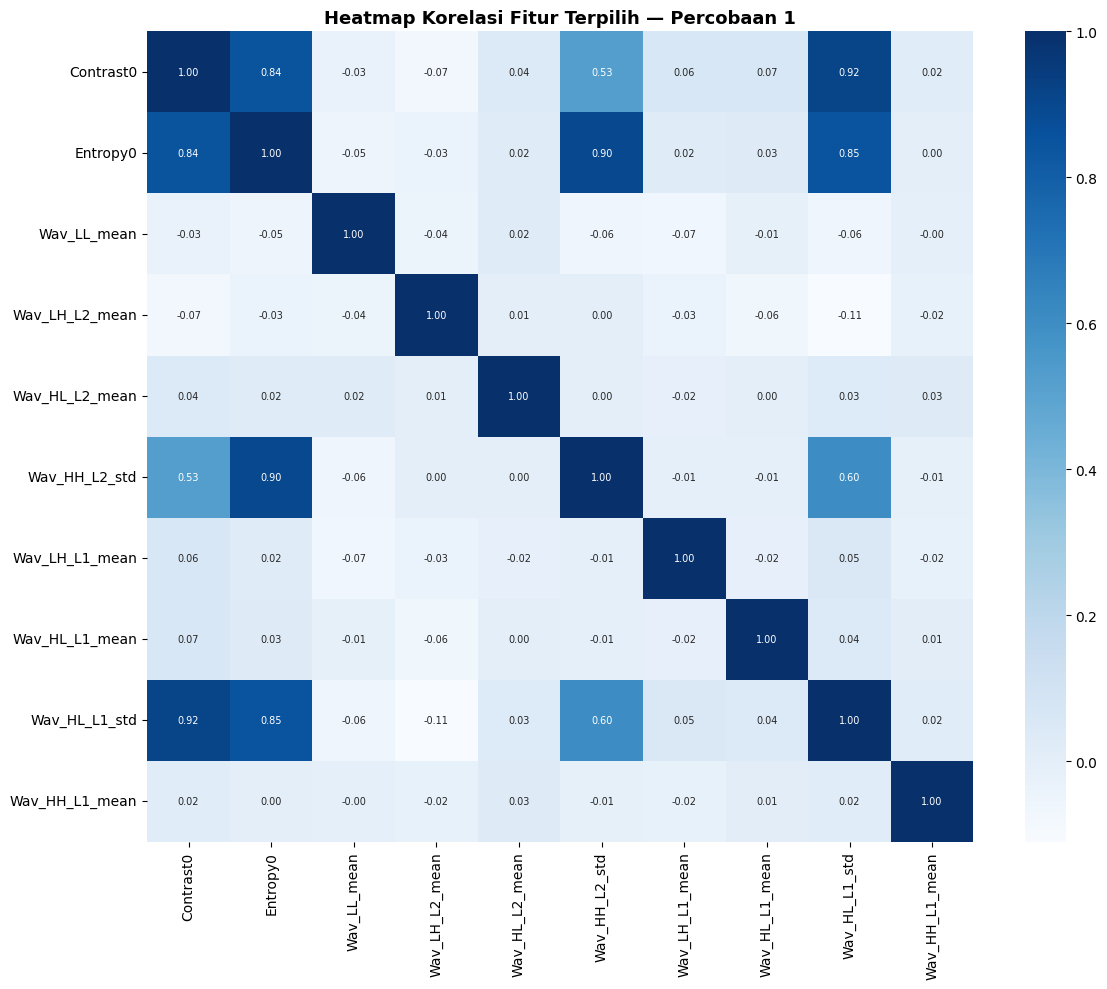

In [35]:
plt.figure(figsize=(max(12, x_new.shape[1]), max(10, x_new.shape[1])))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f",
            annot_kws={'size': 7})
plt.title('Heatmap Korelasi Fitur Terpilih — Percobaan 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Normalisasi Fitur (Z-Score Standardization)

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    x_new, y, test_size=0.2, random_state=42, stratify=y
)

train_mean = X_train.mean()
train_std  = X_train.std()

# Hindari pembagian dengan nol
train_std = train_std.replace(0, 1)

X_train_norm = (X_train - train_mean) / train_std
X_test_norm  = (X_test  - train_mean) / train_std

print("Normalisasi Z-Score selesai!")
print(f"   X_train setelah normalisasi: mean ≈ {X_train_norm.mean().mean():.4f}, std ≈ {X_train_norm.std().mean():.4f}")
print(f"   X_test  setelah normalisasi: mean ≈ {X_test_norm.mean().mean():.4f}")

Normalisasi Z-Score selesai!
   X_train setelah normalisasi: mean ≈ -0.0000, std ≈ 1.0000
   X_test  setelah normalisasi: mean ≈ 0.0112


## 11. Pemodelan & Klasifikasi

In [37]:
def generateClassificationReport(y_true, y_pred, set_name=""):
    print(f"\n{'='*55}")
    print(f"  {set_name}")
    print(f"{'='*55}")
    print(classification_report(y_true, y_pred))
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    return acc, prec, rec, f1

# Definisi model
rf  = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

print("Model berhasil didefinisikan!")
print("   - Random Forest  : n_estimators=100")
print("   - SVM            : kernel=RBF, C=1.0")
print("   - KNN            : n_neighbors=5")

Model berhasil didefinisikan!
   - Random Forest  : n_estimators=100
   - SVM            : kernel=RBF, C=1.0
   - KNN            : n_neighbors=5


In [38]:
print("\n RANDOM FOREST CLASSIFIER")
print("="*55)

rf.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_rf_train = rf.predict(X_train_norm)
rf_train_acc, rf_train_prec, rf_train_rec, rf_train_f1 = generateClassificationReport(
    y_train, y_pred_rf_train, "RF — Training Set")

print("\n---------- Testing Set ----------")
y_pred_rf_test = rf.predict(X_test_norm)
rf_test_acc, rf_test_prec, rf_test_rec, rf_test_f1 = generateClassificationReport(
    y_test, y_pred_rf_test, "RF — Testing Set")


 RANDOM FOREST CLASSIFIER

---------- Training Set ----------

  RF — Training Set
              precision    recall  f1-score   support

       blast       1.00      1.00      1.00       256
      blight       1.00      1.00      1.00       256
      tungro       1.00      1.00      1.00       256

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768

  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000

---------- Testing Set ----------

  RF — Testing Set
              precision    recall  f1-score   support

       blast       0.74      0.78      0.76        64
      blight       0.83      0.91      0.87        64
      tungro       0.81      0.69      0.75        64

    accuracy                           0.79       192
   macro avg       0.79      0.79      0.79       192
weighted avg       0.79      0.79      0.79       192

  Accuracy  : 0

In [39]:
print("\n  SVM CLASSIFIER")
print("="*55)

svm.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_svm_train = svm.predict(X_train_norm)
svm_train_acc, svm_train_prec, svm_train_rec, svm_train_f1 = generateClassificationReport(
    y_train, y_pred_svm_train, "SVM — Training Set")

print("\n---------- Testing Set ----------")
y_pred_svm_test = svm.predict(X_test_norm)
svm_test_acc, svm_test_prec, svm_test_rec, svm_test_f1 = generateClassificationReport(
    y_test, y_pred_svm_test, "SVM — Testing Set")


  SVM CLASSIFIER

---------- Training Set ----------

  SVM — Training Set
              precision    recall  f1-score   support

       blast       0.65      0.78      0.71       256
      blight       0.87      0.78      0.82       256
      tungro       0.75      0.69      0.72       256

    accuracy                           0.75       768
   macro avg       0.76      0.75      0.75       768
weighted avg       0.76      0.75      0.75       768

  Accuracy  : 0.7474
  Precision : 0.7573
  Recall    : 0.7474
  F1-Score  : 0.7493

---------- Testing Set ----------

  SVM — Testing Set
              precision    recall  f1-score   support

       blast       0.56      0.62      0.59        64
      blight       0.76      0.83      0.79        64
      tungro       0.76      0.61      0.68        64

    accuracy                           0.69       192
   macro avg       0.70      0.69      0.69       192
weighted avg       0.70      0.69      0.69       192

  Accuracy  : 0.6875
 

In [40]:
print("\n KNN CLASSIFIER")
print("="*55)

knn.fit(X_train_norm, y_train)

print("\n---------- Training Set ----------")
y_pred_knn_train = knn.predict(X_train_norm)
knn_train_acc, knn_train_prec, knn_train_rec, knn_train_f1 = generateClassificationReport(
    y_train, y_pred_knn_train, "KNN — Training Set")

print("\n---------- Testing Set ----------")
y_pred_knn_test = knn.predict(X_test_norm)
knn_test_acc, knn_test_prec, knn_test_rec, knn_test_f1 = generateClassificationReport(
    y_test, y_pred_knn_test, "KNN — Testing Set")


 KNN CLASSIFIER

---------- Training Set ----------

  KNN — Training Set
              precision    recall  f1-score   support

       blast       0.63      0.77      0.69       256
      blight       0.77      0.79      0.78       256
      tungro       0.79      0.59      0.67       256

    accuracy                           0.72       768
   macro avg       0.73      0.72      0.71       768
weighted avg       0.73      0.72      0.71       768

  Accuracy  : 0.7161
  Precision : 0.7286
  Recall    : 0.7161
  F1-Score  : 0.7150

---------- Testing Set ----------

  KNN — Testing Set
              precision    recall  f1-score   support

       blast       0.48      0.56      0.52        64
      blight       0.65      0.77      0.71        64
      tungro       0.76      0.50      0.60        64

    accuracy                           0.61       192
   macro avg       0.63      0.61      0.61       192
weighted avg       0.63      0.61      0.61       192

  Accuracy  : 0.6094
  

## 12. Evaluasi — Confusion Matrix

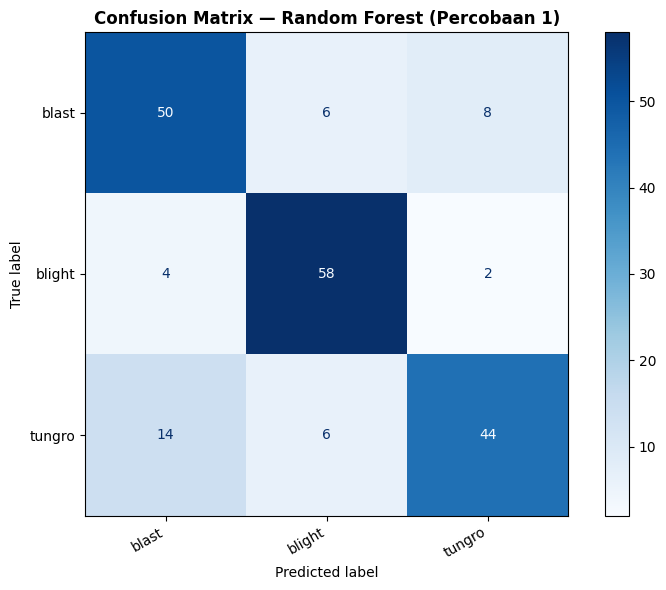

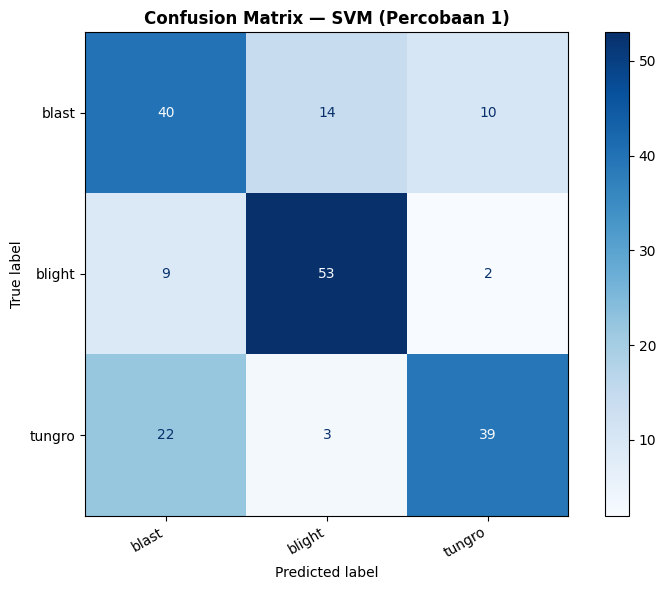

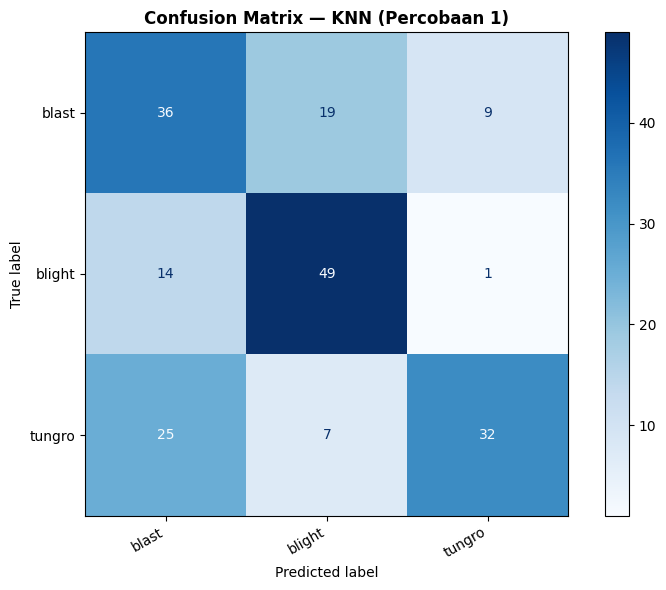

In [41]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=np.unique(y_true))
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf_test,  "Confusion Matrix — Random Forest (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_svm_test, "Confusion Matrix — SVM (Percobaan 1)")
plot_confusion_matrix(y_test, y_pred_knn_test, "Confusion Matrix — KNN (Percobaan 1)")

## 13. Ringkasan Hasil Percobaan 1

In [42]:
hasil_summary = pd.DataFrame({
    'Model': ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train' : [rf_train_acc,  svm_train_acc,  knn_train_acc],
    'Accuracy_Test'  : [rf_test_acc,   svm_test_acc,   knn_test_acc],
    'Precision_Test' : [rf_test_prec,  svm_test_prec,  knn_test_prec],
    'Recall_Test'    : [rf_test_rec,   svm_test_rec,   knn_test_rec],
    'F1_Score_Test'  : [rf_test_f1,    svm_test_f1,    knn_test_f1],
})

print(hasil_summary.to_string(index=False))

hasil_summary.to_csv('hasil_percobaan1.csv', index=False)

        Model  Accuracy_Train  Accuracy_Test  Precision_Test  Recall_Test  F1_Score_Test
Random Forest        1.000000       0.791667        0.792893     0.791667       0.789670
          SVM        0.747396       0.687500        0.695076     0.687500       0.687299
          KNN        0.716146       0.609375        0.631746     0.609375       0.608932


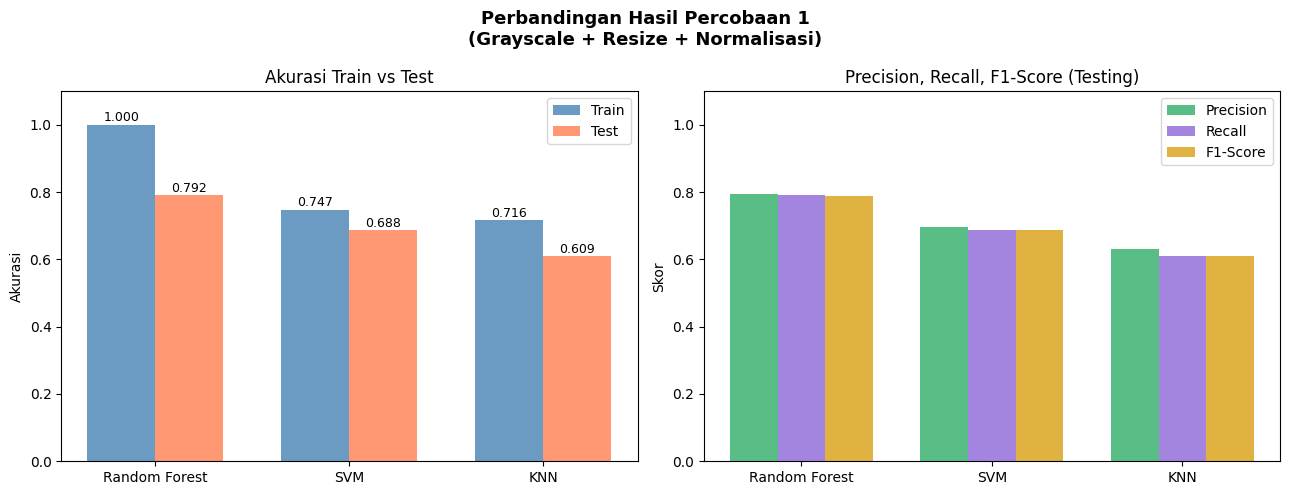

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Perbandingan Hasil Percobaan 1\n(Grayscale + Resize + Normalisasi)',
             fontsize=13, fontweight='bold')

models = hasil_summary['Model']
x = np.arange(len(models))
width = 0.35

# Grafik Akurasi Train vs Test
axes[0].bar(x - width/2, hasil_summary['Accuracy_Train'], width, label='Train', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, hasil_summary['Accuracy_Test'],  width, label='Test',  color='coral',     alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_ylim(0, 1.1)
axes[0].set_ylabel('Akurasi')
axes[0].set_title('Akurasi Train vs Test')
axes[0].legend()
for xi, (tr, te) in enumerate(zip(hasil_summary['Accuracy_Train'], hasil_summary['Accuracy_Test'])):
    axes[0].text(xi - width/2, tr + 0.01, f"{tr:.3f}", ha='center', fontsize=9)
    axes[0].text(xi + width/2, te + 0.01, f"{te:.3f}", ha='center', fontsize=9)

# Grafik Precision, Recall, F1
w = 0.25
axes[1].bar(x - w, hasil_summary['Precision_Test'], w, label='Precision', color='mediumseagreen', alpha=0.85)
axes[1].bar(x,     hasil_summary['Recall_Test'],    w, label='Recall',    color='mediumpurple',   alpha=0.85)
axes[1].bar(x + w, hasil_summary['F1_Score_Test'],  w, label='F1-Score',  color='goldenrod',      alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('Skor')
axes[1].set_title('Precision, Recall, F1-Score (Testing)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [44]:
dataPreprocessed = []

for i in range(len(data_augmented)):
    img_prep = prepro3(data_augmented[i], TARGET_SIZE)
    dataPreprocessed.append(img_prep)

dataPreprocessed = np.array(dataPreprocessed)

print(f"   Preprocessing selesai!")
print(f"   Jumlah gambar    : {len(dataPreprocessed)}")
print(f"   Ukuran gambar    : {dataPreprocessed[0].shape}")
print(f"   Tipe data        : {dataPreprocessed[0].dtype}")
print(f"   Nilai min / max  : {dataPreprocessed[0].min()} / {dataPreprocessed[0].max()}")

NameError: name 'prepro3' is not defined

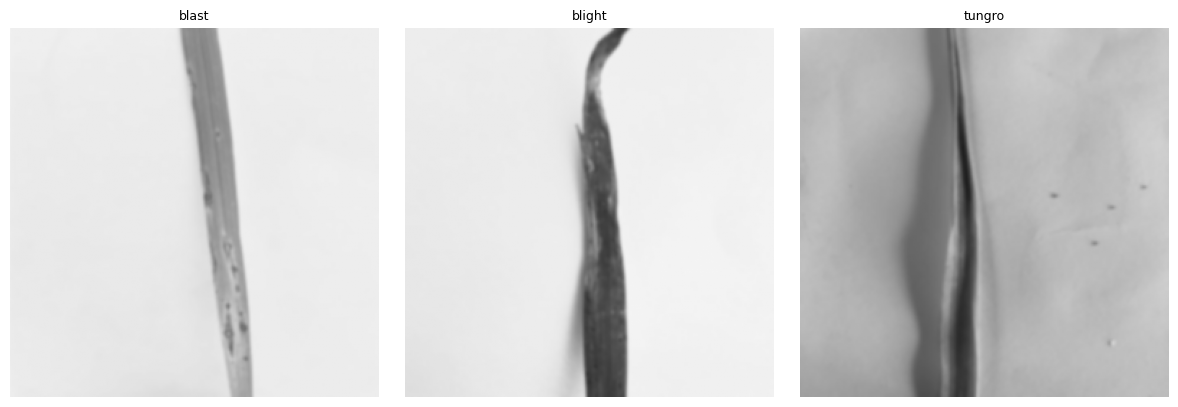

In [ ]:
unique_labels = np.unique(labels_augmented)
fig, axes = plt.subplots(1, len(unique_labels), figsize=(4 * len(unique_labels), 4))

for ax, kelas in zip(axes, unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]
    ax.imshow(dataPreprocessed[idx], cmap='gray', vmin=0, vmax=255)
    ax.set_title(kelas, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

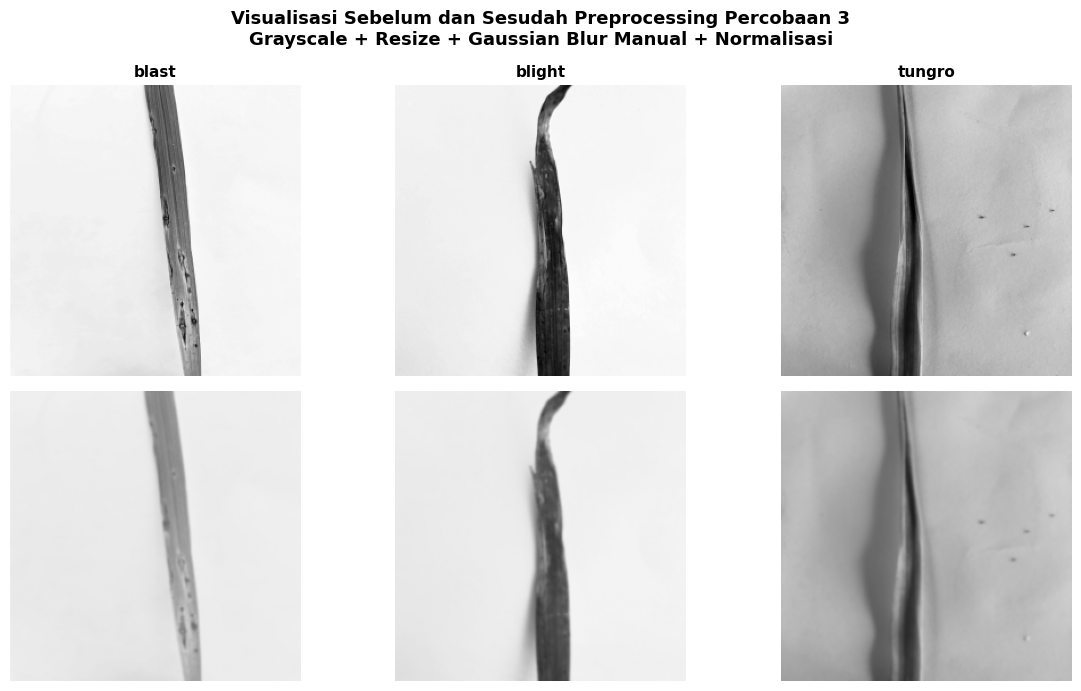

In [ ]:
# VISUALISASI PERBANDINGAN SEBELUM DAN SESUDAH PREPROCESSING

unique_labels = np.unique(labels_augmented)
n_kelas = len(unique_labels)
fig, axes = plt.subplots(2, n_kelas, figsize=(12, 7))

for col, kelas in enumerate(unique_labels):
    idx = np.where(labels_augmented == kelas)[0][0]

    gambar_asli = data_augmented[idx].astype(np.uint8)
    gambar_prepro = dataPreprocessed[idx]

    # [PERUBAHAN] Baris 1: sebelum preprocessing
    axes[0, col].imshow(gambar_asli, cmap='gray')
    axes[0, col].set_title(f"{kelas}", fontsize=11, fontweight='bold')
    axes[0, col].set_ylabel("Sebelum", fontsize=11)
    axes[0, col].axis('off')

    # [PERUBAHAN] Baris 2: sesudah preprocessing
    axes[1, col].imshow(gambar_prepro, cmap='gray', vmin=0, vmax=255)
    axes[1, col].set_ylabel("Sesudah", fontsize=11)
    axes[1, col].axis('off')

plt.suptitle(
    "Visualisasi Sebelum dan Sesudah Preprocessing Percobaan 3\n"
    "Grayscale + Resize + Gaussian Blur Manual + Normalisasi",
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()